In [185]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [186]:
df = pd.read_csv(r"C:\Users\newbl\OneDrive\Desktop\Sale and demand forecaster\data\Sales Dataset.csv") 
df.head()

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City,Year-Month
0,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
1,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12
2,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2021-07-25,Robert Stone,New York,Buffalo,2021-07
3,B-26776,4975,1330,14,Electronics,Printers,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
4,B-26776,4975,1330,14,Electronics,Printers,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12


In [187]:
df = df.drop(columns=["Order ID", "CustomerName"])
df.head()

,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,State,City,Year-Month
0,9726,1275,5,Electronics,Electronic Games,UPI,2023-06-27,Florida,Miami,2023-06
1,9726,1275,5,Electronics,Electronic Games,UPI,2024-12-27,Illinois,Chicago,2024-12
2,9726,1275,5,Electronics,Electronic Games,UPI,2021-07-25,New York,Buffalo,2021-07
3,4975,1330,14,Electronics,Printers,UPI,2023-06-27,Florida,Miami,2023-06
4,4975,1330,14,Electronics,Printers,UPI,2024-12-27,Illinois,Chicago,2024-12


In [188]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Amount        1194 non-null   int64 
 1   Profit        1194 non-null   int64 
 2   Quantity      1194 non-null   int64 
 3   Category      1194 non-null   object
 4   Sub-Category  1194 non-null   object
 5   PaymentMode   1194 non-null   object
 6   Order Date    1194 non-null   object
 7   State         1194 non-null   object
 8   City          1194 non-null   object
 9   Year-Month    1194 non-null   object
dtypes: int64(3), object(7)
memory usage: 93.4+ KB


In [189]:
df.describe(include="object")

,Category,Sub-Category,PaymentMode,Order Date,State,City,Year-Month
count,1194,1194,1194,1194,1194,1194,1194
unique,3,12,5,648,6,18,61
top,Furniture,Tables,Debit Card,2022-12-08,New York,Buffalo,2022-12
freq,407,122,260,8,226,90,45


In [190]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Order Date"].dtype

dtype('<M8[ns]')

In [191]:
print("Start date:", df["Order Date"].min())
print("End date:", df["Order Date"].max())

Start date: 2020-03-22 00:00:00
End date: 2025-03-15 00:00:00


In [192]:
df["Quantity"].describe()

count    1194.000000
mean       10.674204
std         5.777102
min         1.000000
25%         6.000000
50%        11.000000
75%        16.000000
max        20.000000
Name: Quantity, dtype: float64

In [193]:
df["Quantity"].value_counts().sort_index().head(10)

Quantity
1     61
2     46
3     58
4     60
5     70
6     60
7     59
8     57
9     53
10    58
Name: count, dtype: int64

In [194]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDate range:")
print(df["Order Date"].min(), "to", df["Order Date"].max())

print("\nQuantity statistics:")
print(df["Quantity"].describe())

Shape: (1194, 10)

Columns:
['Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category', 'PaymentMode', 'Order Date', 'State', 'City', 'Year-Month']

Data types:
Amount                   int64
Profit                   int64
Quantity                 int64
Category                object
Sub-Category            object
PaymentMode             object
Order Date      datetime64[ns]
State                   object
City                    object
Year-Month              object
dtype: object

Missing values:
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
PaymentMode     0
Order Date      0
State           0
City            0
Year-Month      0
dtype: int64

Duplicate rows: 0

Date range:
2020-03-22 00:00:00 to 2025-03-15 00:00:00

Quantity statistics:
count    1194.000000
mean       10.674204
std         5.777102
min         1.000000
25%         6.000000
50%        11.000000
75%        16.000000
max        20.000000
Name: Quantity, dtype: float64


In [195]:
df[["Amount", "Profit", "Quantity"]].describe()

,Amount,Profit,Quantity
count,1194.000000,1194.000000,1194.000000
mean,5178.089615,1348.992462,10.674204
std,2804.921955,1117.992573,5.777102
min,508.000000,50.000000,1.000000
25%,2799.000000,410.000000,6.000000
50%,5152.000000,1014.000000,11.000000
75%,7626.000000,2035.000000,16.000000
max,9992.000000,4930.000000,20.000000


In [196]:
print("Negative Amount:", (df["Amount"] < 0).sum())
print("Negative Profit:", (df["Profit"] < 0).sum())
print("Zero Quantity:", (df["Quantity"] == 0).sum())
print("Negative Quantity:", (df["Quantity"] < 0).sum())

Negative Amount: 0
Negative Profit: 0
Zero Quantity: 0
Negative Quantity: 0


In [197]:
categorical_columns = ["Category", "Sub-Category", "PaymentMode", "State", "City"]

for column in categorical_columns:
    print(f"\n{column}")
    print("Unique values:", df[column].nunique())
    print(df[column].unique())


Category
Unique values: 3
['Electronics' 'Office Supplies' 'Furniture']

Sub-Category
Unique values: 12
['Electronic Games' 'Printers' 'Pens' 'Laptops' 'Tables' 'Chairs'
 'Markers' 'Sofas' 'Paper' 'Binders' 'Phones' 'Bookcases']

PaymentMode
Unique values: 5
['UPI' 'Debit Card' 'EMI' 'Credit Card' 'COD']

State
Unique values: 6
['Florida' 'Illinois' 'New York' 'California' 'Texas' 'Ohio']

City
Unique values: 18
['Miami' 'Chicago' 'Buffalo' 'Orlando' 'Los Angeles' 'New York City'
 'Springfield' 'Rochester' 'Dallas' 'San Diego' 'Austin' 'San Francisco'
 'Columbus' 'Cincinnati' 'Cleveland' 'Houston' 'Tampa' 'Peoria']


In [198]:
df.duplicated().sum()

np.int64(0)

In [199]:
df["Order Date"].value_counts().sort_index().head(10)

Order Date
2020-03-22    1
2020-03-23    1
2020-03-31    2
2020-04-02    2
2020-04-04    3
2020-04-05    1
2020-04-08    4
2020-04-13    2
2020-04-16    1
2020-04-18    3
Name: count, dtype: int64

In [200]:
print(df["Year-Month"].nunique())

61


In [201]:
print(df["Quantity"].value_counts().sort_index().head(10))

Quantity
1     61
2     46
3     58
4     60
5     70
6     60
7     59
8     57
9     53
10    58
Name: count, dtype: int64


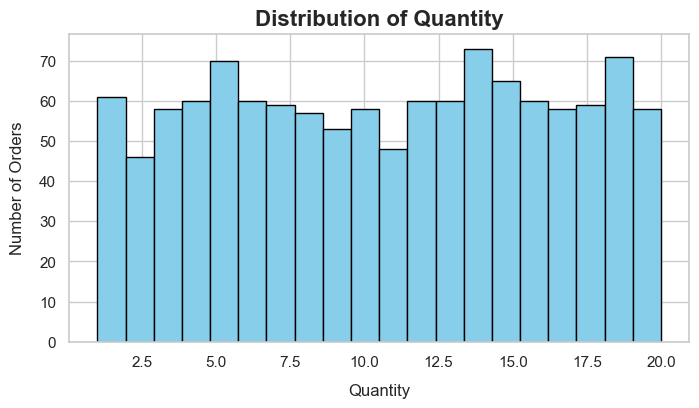

In [202]:
plt.figure(figsize=(8, 4))
plt.hist(df["Quantity"], bins=20, edgecolor="black", color="skyblue")
plt.xlabel("Quantity", fontsize=12, labelpad=10)
plt.ylabel("Number of Orders", fontsize=12, labelpad=10)
plt.title("Distribution of Quantity", fontsize=16, fontweight="bold")
plt.show()

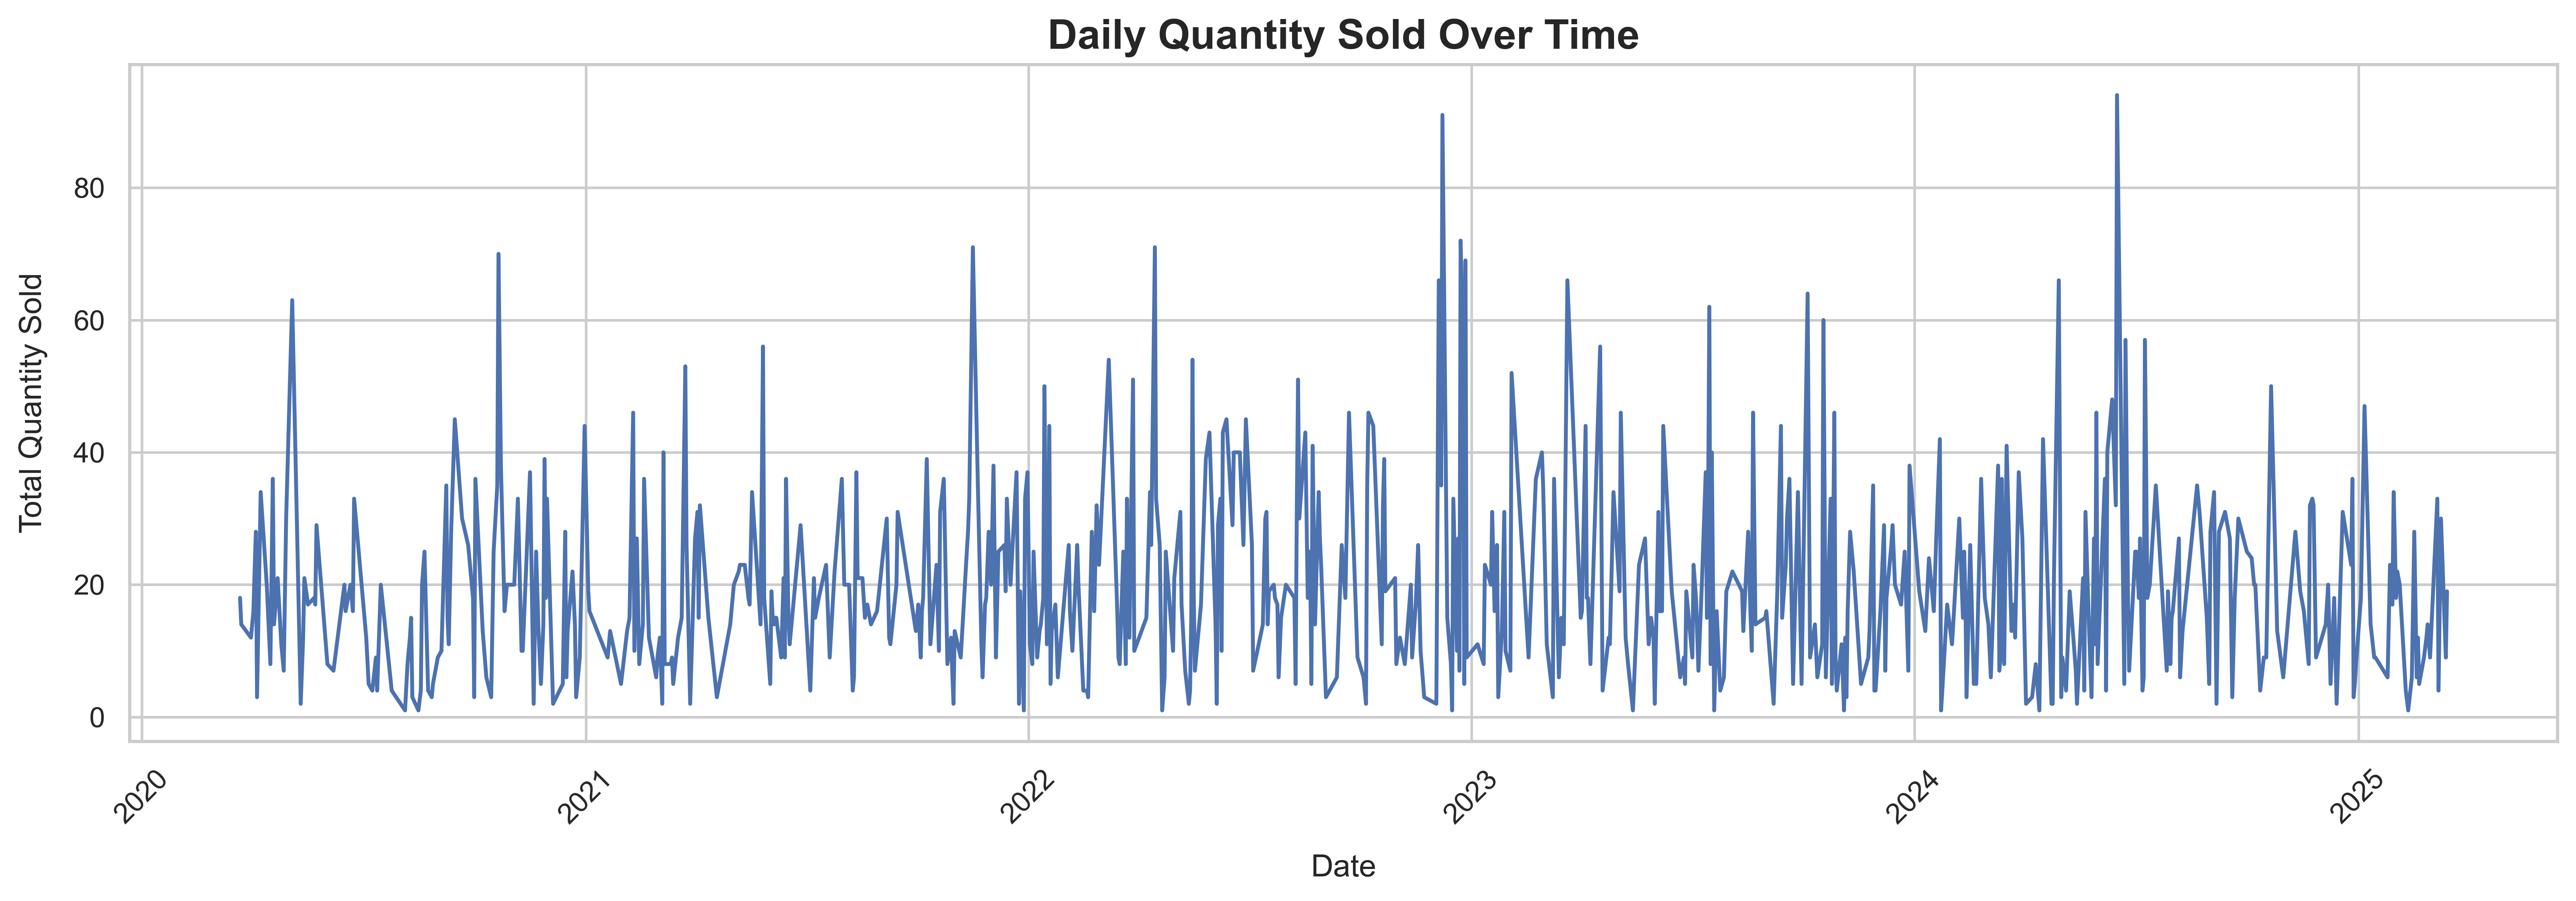

In [203]:
daily_sales = df.groupby("Order Date")["Quantity"].sum()
plt.figure(figsize=(14, 5), dpi=500)
plt.plot(daily_sales.index, daily_sales.values)
plt.xlabel("Date", fontsize=12, labelpad=10)
plt.ylabel("Total Quantity Sold", fontsize=12, labelpad=10)
plt.title("Daily Quantity Sold Over Time", fontsize=16, fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [204]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month_Name"] = df["Order Date"].dt.month_name()
df["Day"] = df["Order Date"].dt.day
df["Day_of_Week"] = df["Order Date"].dt.dayofweek
df["Week"] = df["Order Date"].dt.isocalendar().week

In [205]:
df["Is_Weekend"] = df["Day_of_Week"].isin([5, 6]).astype(int)
df.head()

,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,State,City,Year-Month,Year,Month,Month_Name,Day,Day_of_Week,Week,Is_Weekend
0,9726,1275,5,Electronics,Electronic Games,UPI,2023-06-27,Florida,Miami,2023-06,2023,6,June,27,1,26,0
1,9726,1275,5,Electronics,Electronic Games,UPI,2024-12-27,Illinois,Chicago,2024-12,2024,12,December,27,4,52,0
2,9726,1275,5,Electronics,Electronic Games,UPI,2021-07-25,New York,Buffalo,2021-07,2021,7,July,25,6,29,1
3,4975,1330,14,Electronics,Printers,UPI,2023-06-27,Florida,Miami,2023-06,2023,6,June,27,1,26,0
4,4975,1330,14,Electronics,Printers,UPI,2024-12-27,Illinois,Chicago,2024-12,2024,12,December,27,4,52,0


In [206]:
monthly_demand = (df.groupby("Year-Month")["Quantity"].sum().sort_index())
print(monthly_demand)

Year-Month
2020-03     44
2020-04    228
2020-05    229
2020-06    120
2020-07     58
          ... 
2024-11    177
2024-12    182
2025-01    177
2025-02    157
2025-03    104
Name: Quantity, Length: 61, dtype: int64


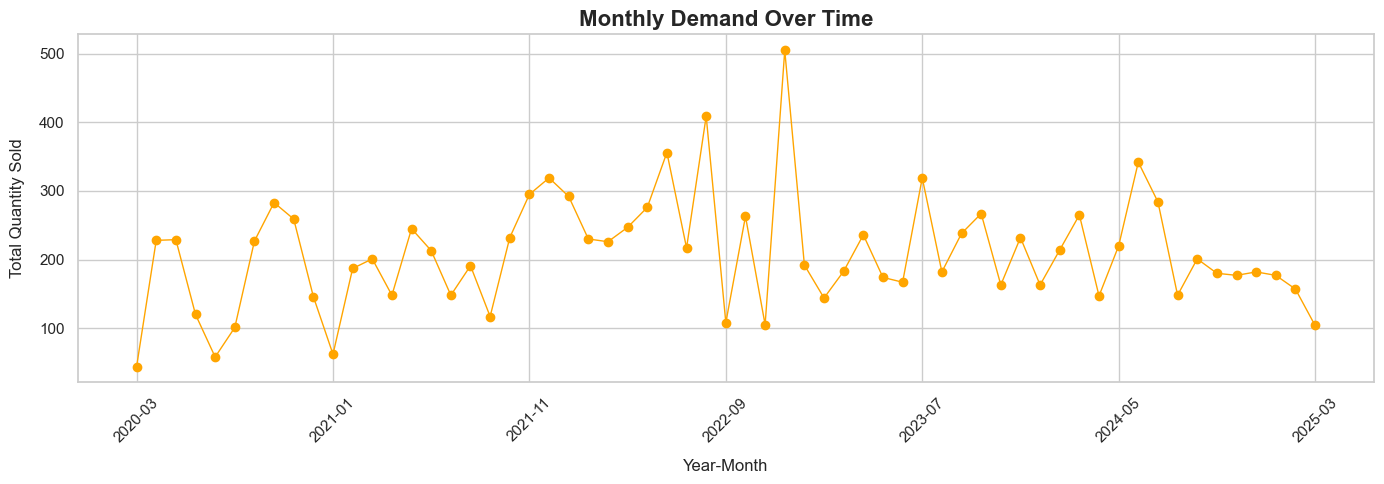

In [207]:
monthly_demand.plot(figsize=(14, 5), marker="o", color="orange", linewidth=1, markersize=6)
plt.title("Monthly Demand Over Time", fontsize=16, fontweight="bold")
plt.xlabel("Year-Month", fontsize=12, labelpad=10)
plt.ylabel("Total Quantity Sold", fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Category
Furniture          4441
Electronics        4258
Office Supplies    4046
Name: Quantity, dtype: int64


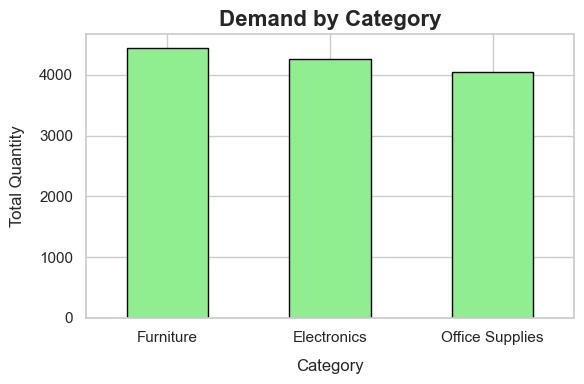

In [208]:
category_demand = (df.groupby("Category")["Quantity"].sum().sort_values(ascending=False))
print(category_demand)

plt.figure(figsize=(6, 4))
category_demand.plot(kind="bar", edgecolor="black", color="lightgreen", width=0.5)
plt.xlabel("Category", fontsize=12, labelpad=10)
plt.ylabel("Total Quantity", fontsize=12, labelpad=10)
plt.title("Demand by Category", fontsize=16, fontweight="bold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Sub-Category
Tables              1303
Sofas               1233
Electronic Games    1220
Pens                1204
Markers             1173
Printers            1124
Bookcases           1030
Paper                981
Phones               980
Laptops              934
Chairs               875
Binders              688
Name: Quantity, dtype: int64


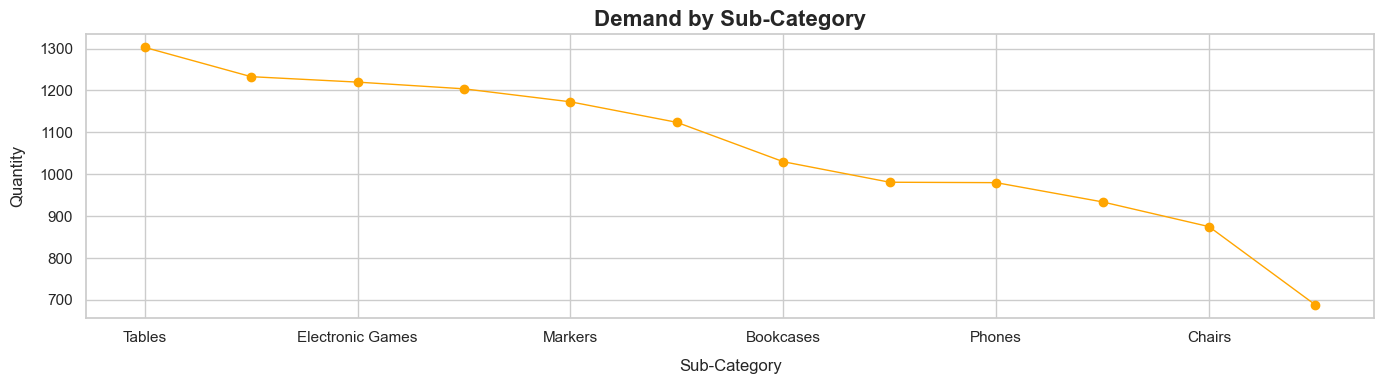

In [209]:
subcategory_demand = (df.groupby("Sub-Category")["Quantity"].sum().sort_values(ascending=False))
print(subcategory_demand)

subcategory_demand.plot(figsize=(14, 4), marker="o", color="orange", linewidth=1, markersize=6)
plt.title("Demand by Sub-Category", fontsize=16, fontweight="bold")
plt.xlabel("Sub-Category", fontsize=12, labelpad=10)
plt.ylabel("Quantity", fontsize=12, labelpad=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

State
New York      2479
California    2319
Florida       2145
Ohio          2041
Texas         1941
Illinois      1820
Name: Quantity, dtype: int64


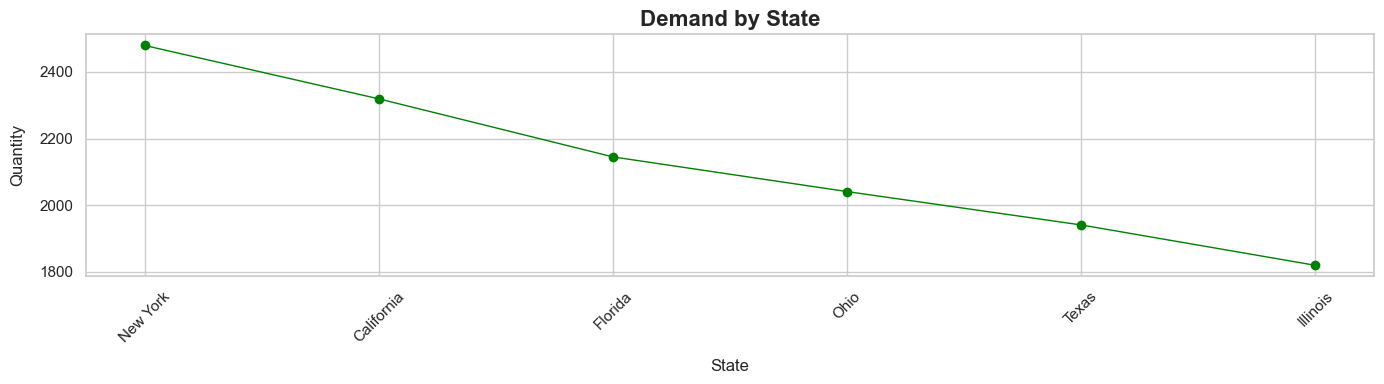

In [210]:
state_demand = (df.groupby("State")["Quantity"].sum().sort_values(ascending=False))
print(state_demand)

state_demand.plot(figsize=(14, 4), marker="o", color="green", linewidth=1, markersize=6)
plt.title("Demand by State", fontsize=16, fontweight="bold")
plt.xlabel("State", fontsize=12, labelpad=10)
plt.ylabel("Quantity", fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [211]:
numeric_columns = ["Amount", "Profit", "Quantity", "Year", "Month", "Day", "Day_of_Week", "Week", "Is_Weekend"]
correlation = df[numeric_columns].corr()
print(correlation["Quantity"].sort_values(ascending=False))

Quantity       1.000000
Profit         0.066088
Amount         0.044631
Month          0.020521
Week           0.018815
Year           0.004634
Day_of_Week    0.000285
Is_Weekend    -0.002318
Day           -0.003968
Name: Quantity, dtype: float64


In [212]:
categorical_cols = ['Category', 'Sub-Category', 'PaymentMode', 'State', 'City']

for col in categorical_cols:
    print(f"\nAverage Quantity by {col}:")
    print(df.groupby(col)['Quantity'].mean().sort_values(ascending=False))


Average Quantity by Category:
Category
Electronics        10.974227
Furniture          10.911548
Office Supplies    10.140351
Name: Quantity, dtype: float64

Average Quantity by Sub-Category:
Sub-Category
Printers            11.831579
Electronic Games    11.730769
Bookcases           11.704545
Sofas               10.815789
Tables              10.680328
Markers             10.663636
Laptops             10.613636
Pens                10.561404
Chairs              10.542169
Phones               9.702970
Binders              9.690141
Paper                9.432692
Name: Quantity, dtype: float64

Average Quantity by PaymentMode:
PaymentMode
EMI            10.876147
UPI            10.813492
Debit Card     10.665385
COD            10.635922
Credit Card    10.406977
Name: Quantity, dtype: float64

Average Quantity by State:
State
Ohio          11.338889
New York      10.969027
Florida       10.725000
California    10.637615
Texas         10.269841
Illinois      10.055249
Name: Quantity, dtype: 

In [213]:
for col in ['Category', 'Sub-Category', 'PaymentMode', 'State', 'City']:
    print(f"\n===== {col} =====")
    print(df[col].value_counts())


===== Category =====
Category
Furniture          407
Office Supplies    399
Electronics        388
Name: count, dtype: int64

===== Sub-Category =====
Sub-Category
Tables              122
Pens                114
Sofas               114
Markers             110
Electronic Games    104
Paper               104
Phones              101
Printers             95
Laptops              88
Bookcases            88
Chairs               83
Binders              71
Name: count, dtype: int64

===== PaymentMode =====
PaymentMode
Debit Card     260
Credit Card    258
UPI            252
EMI            218
COD            206
Name: count, dtype: int64

===== State =====
State
New York      226
California    218
Florida       200
Texas         189
Illinois      181
Ohio          180
Name: count, dtype: int64

===== City =====
City
Buffalo          90
San Francisco    84
Orlando          77
Rochester        74
San Diego        73
Dallas           72
Cleveland        70
Springfield      68
Miami            66
A

In [214]:
target = 'Quantity'

X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())

X shape: (1194, 16)
y shape: (1194,)

Features:
['Amount', 'Profit', 'Category', 'Sub-Category', 'PaymentMode', 'Order Date', 'State', 'City', 'Year-Month', 'Year', 'Month', 'Month_Name', 'Day', 'Day_of_Week', 'Week', 'Is_Weekend']


In [215]:
df = df.sort_values('Order Date').reset_index(drop=True)

target = 'Quantity'

X = df.drop(columns=[target])
y = df[target]

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining period:")
print(X_train['Order Date'].min(), "to", X_train['Order Date'].max())

print("\nTesting period:")
print(X_test['Order Date'].min(), "to", X_test['Order Date'].max())

Training set: (955, 16)
Testing set: (239, 16)

Training period:
2020-03-22 00:00:00 to 2024-03-17 00:00:00

Testing period:
2024-03-17 00:00:00 to 2025-03-15 00:00:00


In [216]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

categorical_features = ['Category','Sub-Category','PaymentMode','State','City','Month_Name']

numerical_features = ['Amount','Profit','Year','Month','Day','Day_of_Week','Week','Is_Weekend']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [217]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_model = Pipeline([('preprocessor', preprocessor),('model', LinearRegression())])

linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", f"{mae:.4f}")
print("RMSE:", f"{rmse:.4f}")
print("R²  :", f"{r2:.4f}")

Linear Regression Results
-------------------------
MAE : 5.3138
RMSE: 6.0893
R²  : -0.0577


In [218]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print("MAE :", f"{rf_mae:.4f}")
print("RMSE:", f"{rf_rmse:.4f}")
print("R²  :", f"{rf_r2:.4f}")

Random Forest Results
---------------------
MAE : 4.9744
RMSE: 5.7770
R²  : 0.0480


In [219]:
comparison = pd.DataFrame({'Actual Quantity': y_test.values, 'Predicted Quantity': rf_pred})
print(comparison.head(10))

   Actual Quantity  Predicted Quantity
0               15           12.030000
1                9           10.953333
2               13           10.246667
3               17           12.173333
4               12           13.636667
5                5            9.750000
6               11           10.210000
7               17           10.763333
8                4            8.910000
9               11           12.530000


In [220]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Results")
print("-------------------------")
print("MAE :", round(gb_mae, 4))
print("RMSE:", round(gb_rmse, 4))
print("R²  :", round(gb_r2, 4))

Gradient Boosting Results
-------------------------
MAE : 4.8114
RMSE: 5.637
R²  : 0.0936


In [221]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

cv_scores = cross_val_score(gb_model, X_train, y_train, cv=tscv, scoring='r2')
print("Time Series Cross-Validation R² scores:")
print(cv_scores)

print("\nMean R²:", round(cv_scores.mean(), 4))
print("Standard Deviation:", round(cv_scores.std(), 4))

Time Series Cross-Validation R² scores:
[-0.23965065 -0.20715261 -0.062796   -0.03338082 -0.01551852]

Mean R²: -0.1117
Standard Deviation: 0.093


In [222]:
naive_prediction = np.full(len(y_test), y_train.mean())

naive_mae = mean_absolute_error(y_test, naive_prediction)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_prediction))
naive_r2 = r2_score(y_test, naive_prediction)

print("Naive Baseline Results")
print("----------------------")
print("MAE :", round(naive_mae, 4))
print("RMSE:", round(naive_rmse, 4))
print("R²  :", round(naive_r2, 4))

Naive Baseline Results
----------------------
MAE : 5.2135
RMSE: 5.9449
R²  : -0.0081


In [223]:
daily_quantity = df.groupby('Order Date')['Quantity'].sum()

print(daily_quantity.describe())
print("\nNumber of unique dates:", daily_quantity.index.nunique())
print("\nFirst 10 daily quantities:")
print(daily_quantity.head(10))

count    648.000000
mean      19.668210
std       14.586716
min        1.000000
25%        9.000000
50%       16.000000
75%       28.000000
max       94.000000
Name: Quantity, dtype: float64

Number of unique dates: 648

First 10 daily quantities:
Order Date
2020-03-22    18
2020-03-23    14
2020-03-31    12
2020-04-02    16
2020-04-04    28
2020-04-05     3
2020-04-08    34
2020-04-13    20
2020-04-16     8
2020-04-18    36
Name: Quantity, dtype: int64


In [224]:
daily_quantity = df.groupby('Order Date')['Quantity'].sum()

print("First date:", daily_quantity.index.min())
print("Last date:", daily_quantity.index.max())

print("\nMonthly average quantity:")
print(daily_quantity.resample('ME').mean().head(12))

print("\nMonthly total quantity:")
print(daily_quantity.resample('ME').sum().head(12))

First date: 2020-03-22 00:00:00
Last date: 2025-03-15 00:00:00

Monthly average quantity:
Order Date
2020-03-31    14.666667
2020-04-30    19.000000
2020-05-31    25.444444
2020-06-30    17.142857
2020-07-31     8.285714
2020-08-31     8.416667
2020-09-30    22.700000
2020-10-31    23.583333
2020-11-30    19.923077
2020-12-31    14.600000
2021-01-31    12.400000
2021-02-28    18.700000
Freq: ME, Name: Quantity, dtype: float64

Monthly total quantity:
Order Date
2020-03-31     44
2020-04-30    228
2020-05-31    229
2020-06-30    120
2020-07-31     58
2020-08-31    101
2020-09-30    227
2020-10-31    283
2020-11-30    259
2020-12-31    146
2021-01-31     62
2021-02-28    187
Freq: ME, Name: Quantity, dtype: int64


In [225]:
monthly_demand = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Quantity'].sum()

monthly_demand = monthly_demand.to_timestamp()

print(monthly_demand.head(12))
print("\nShape:", monthly_demand.shape)
print("\nDate range:", monthly_demand.index.min(), "to", monthly_demand.index.max())
print("\nSummary:")
print(monthly_demand.describe())

Order Date
2020-03-01     44
2020-04-01    228
2020-05-01    229
2020-06-01    120
2020-07-01     58
2020-08-01    101
2020-09-01    227
2020-10-01    283
2020-11-01    259
2020-12-01    146
2021-01-01     62
2021-02-01    187
Freq: MS, Name: Quantity, dtype: int64

Shape: (61,)

Date range: 2020-03-01 00:00:00 to 2025-03-01 00:00:00

Summary:
count     61.000000
mean     208.934426
std       82.806374
min       44.000000
25%      157.000000
50%      201.000000
75%      247.000000
max      505.000000
Name: Quantity, dtype: float64


In [226]:
forecast_df = monthly_demand.to_frame(name='Quantity')

forecast_df['lag_1'] = forecast_df['Quantity'].shift(1)
forecast_df['lag_2'] = forecast_df['Quantity'].shift(2)
forecast_df['lag_3'] = forecast_df['Quantity'].shift(3)

forecast_df['rolling_mean_3'] = (
    forecast_df['Quantity']
    .shift(1)
    .rolling(window=3)
    .mean()
)

forecast_df = forecast_df.dropna()

print(forecast_df.head(10))
print("\nShape:", forecast_df.shape)

            Quantity  lag_1  lag_2  lag_3  rolling_mean_3
Order Date                                               
2020-06-01       120  229.0  228.0   44.0      167.000000
2020-07-01        58  120.0  229.0  228.0      192.333333
2020-08-01       101   58.0  120.0  229.0      135.666667
2020-09-01       227  101.0   58.0  120.0       93.000000
2020-10-01       283  227.0  101.0   58.0      128.666667
2020-11-01       259  283.0  227.0  101.0      203.666667
2020-12-01       146  259.0  283.0  227.0      256.333333
2021-01-01        62  146.0  259.0  283.0      229.333333
2021-02-01       187   62.0  146.0  259.0      155.666667
2021-03-01       201  187.0   62.0  146.0      131.666667

Shape: (58, 5)


In [227]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = forecast_df.drop(columns='Quantity')
y = forecast_df['Quantity']

split_index = int(len(forecast_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training period:", X_train.index.min(), "to", X_train.index.max())
print("Testing period:", X_test.index.min(), "to", X_test.index.max())

Training samples: 46
Testing samples: 12
Training period: 2020-06-01 00:00:00 to 2024-03-01 00:00:00
Testing period: 2024-04-01 00:00:00 to 2025-03-01 00:00:00


In [228]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_forecast = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_forecast.fit(X_train, y_train)

y_pred = rf_forecast.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Forecasting Random Forest Results")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

Forecasting Random Forest Results
MAE : 62.1956
RMSE: 79.2884
R²  : -0.6604


In [229]:
results = pd.DataFrame({
    'Model': ['Naive Baseline', 'Linear Regression', 'Random Forest',
              'Gradient Boosting', 'Time-Series Random Forest'],
    'MAE': [5.2135, 5.3138, 4.9916, 4.8114, 62.1956],
    'RMSE': [5.9449, 6.0893, 5.7889, 5.6370, 79.2884],
    'R2': [-0.0081, -0.0577, 0.0441, 0.0936, -0.6604]
})

print(results)

                       Model      MAE     RMSE      R2
0             Naive Baseline   5.2135   5.9449 -0.0081
1          Linear Regression   5.3138   6.0893 -0.0577
2              Random Forest   4.9916   5.7889  0.0441
3          Gradient Boosting   4.8114   5.6370  0.0936
4  Time-Series Random Forest  62.1956  79.2884 -0.6604


In [230]:
import joblib

joblib.dump(gb_model, 'C:\\Users\\newbl\\OneDrive\\Desktop\\Sale and demand forecaster\\models\\gradient_boosting_model.pkl')
print("Model saved successfully.")

Model saved successfully.
